SAMPLE RESULTS
----------------------------------------
Within 1 SD : 68.3910%
Within 2 SD : 95.4600%
Within 3 SD : 99.7080%

THEORETICAL RESULTS
----------------------------------------
Within 1 SD : 68.2689%
Within 2 SD : 95.4500%
Within 3 SD : 99.7300%

SAMPLE VS THEORY
----------------------------------------
1 SD → Sample: 68.3910% | Theory: 68.2689%
2 SD → Sample: 95.4600% | Theory: 95.4500%
3 SD → Sample: 99.7080% | Theory: 99.7300%

2 STANDARD DEVIATIONS ABOVE THE MEAN
----------------------------------------
Value = 70
Fraction above this value = 2.2750%

ONE STANDARD DEVIATION ABOVE THE MEAN
----------------------------------------
Value = 60
Percentile = 84.1345%


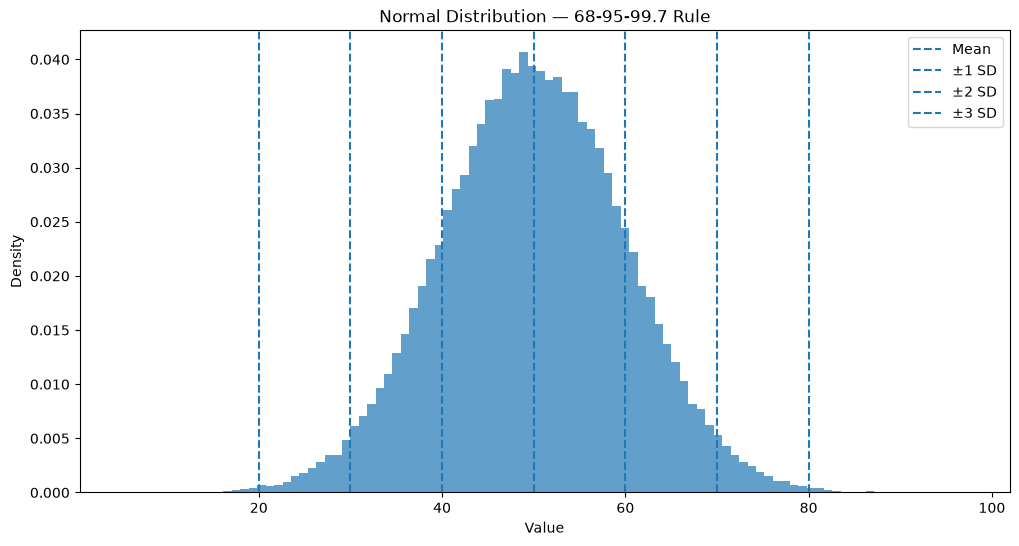

In [1]:
# TASK 02 — THE 68-95-99.7 RULE

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Use the same seed so results are reproducible.
rng = np.random.default_rng(0)

# Generate 100,000 values from a normal distribution.
mu = 50
sigma = 10
N = 100_000

samples = rng.normal(mu, sigma, N)

# 1. SAMPLE-BASED 68-95-99.7 RULE

# Within 1 standard deviation:
# μ - σ < X < μ + σ
within1 = np.mean(np.abs(samples - mu) < sigma)

# Within 2 standard deviations:
# μ - 2σ < X < μ + 2σ
within2 = np.mean(np.abs(samples - mu) < 2 * sigma)

# Within 3 standard deviations:
# μ - 3σ < X < μ + 3σ
within3 = np.mean(np.abs(samples - mu) < 3 * sigma)


print("SAMPLE RESULTS")
print("-" * 40)
print(f"Within 1 SD : {within1:.4%}")
print(f"Within 2 SD : {within2:.4%}")
print(f"Within 3 SD : {within3:.4%}")

# 2. THEORETICAL VALUES USING scipy.stats.norm.cdf

# CDF gives the probability that Z is less than a value.
# For a standard normal distribution:
# P(-1 < Z < 1) = CDF(1) - CDF(-1)

theory1 = stats.norm.cdf(1) - stats.norm.cdf(-1)

theory2 = stats.norm.cdf(2) - stats.norm.cdf(-2)

theory3 = stats.norm.cdf(3) - stats.norm.cdf(-3)


print("\nTHEORETICAL RESULTS")
print("-" * 40)
print(f"Within 1 SD : {theory1:.4%}")
print(f"Within 2 SD : {theory2:.4%}")
print(f"Within 3 SD : {theory3:.4%}")

# 3. COMPARE SAMPLE VS THEORY

print("\nSAMPLE VS THEORY")
print("-" * 40)

print(f"1 SD → Sample: {within1:.4%} | Theory: {theory1:.4%}")
print(f"2 SD → Sample: {within2:.4%} | Theory: {theory2:.4%}")
print(f"3 SD → Sample: {within3:.4%} | Theory: {theory3:.4%}")

# 4. VALUE 2 STANDARD DEVIATIONS ABOVE THE MEAN

# A value 2 SD above the mean has z-score = +2.
x_2sd = mu + 2 * sigma

# P(X > x) = 1 - CDF(x)
above_2sd = 1 - stats.norm.cdf(2)

print("\n2 STANDARD DEVIATIONS ABOVE THE MEAN")
print("-" * 40)
print(f"Value = {x_2sd}")
print(f"Fraction above this value = {above_2sd:.4%}")

# 5. PERCENTILE OF ONE SD ABOVE THE MEAN

# One SD above the mean corresponds to z = +1.
# CDF(1) gives the percentage below this value.
percentile_1sd = stats.norm.cdf(1)

print("\nONE STANDARD DEVIATION ABOVE THE MEAN")
print("-" * 40)
print(f"Value = {mu + sigma}")
print(f"Percentile = {percentile_1sd:.4%}")

# 6. VISUALISE THE NORMAL DISTRIBUTION

plt.figure(figsize=(12, 6))

plt.hist(
    samples,
    bins=100,
    density=True,
    alpha=0.7
)

# Mean
plt.axvline(
    mu,
    linestyle="--",
    label="Mean"
)

# ±1 standard deviation
plt.axvline(
    mu - sigma,
    linestyle="--",
    label="±1 SD"
)

plt.axvline(
    mu + sigma,
    linestyle="--"
)

# ±2 standard deviations
plt.axvline(
    mu - 2 * sigma,
    linestyle="--",
    label="±2 SD"
)

plt.axvline(
    mu + 2 * sigma,
    linestyle="--"
)

# ±3 standard deviations
plt.axvline(
    mu - 3 * sigma,
    linestyle="--",
    label="±3 SD"
)

plt.axvline(
    mu + 3 * sigma,
    linestyle="--"
)

plt.title("Normal Distribution — 68-95-99.7 Rule")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()

plt.show()

# Task 02 — The 68-95-99.7 Rule

## Objective

The 68-95-99.7 rule describes how values are distributed around the mean in a normal distribution.

For a normal distribution:

- About 68% of values are within ±1 standard deviation.
- About 95% of values are within ±2 standard deviations.
- About 99.7% of values are within ±3 standard deviations.

---

# 1. Distribution Used

We selected:

- Mean (μ) = 50
- Standard deviation (σ) = 10
- Number of samples = 100,000

Therefore:

### Within 1 SD

50 ± 10

Range:

40 to 60

Expected percentage:

≈ 68.27%

### Within 2 SD

50 ± 20

Range:

30 to 70

Expected percentage:

≈ 95.45%

### Within 3 SD

50 ± 30

Range:

20 to 80

Expected percentage:

≈ 99.73%

The exact sample percentages may be slightly different because they are calculated from random samples.

---

# 2. Sample Results

The code calculates:

```text
Within 1 SD → approximately 68%
Within 2 SD → approximately 95%
Within 3 SD → approximately 99.7%